## We will first code a simple attention

In [38]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Ganga
   [0.55, 0.87, 0.66], # is
   [0.57, 0.85, 0.64], # a
   [0.22, 0.58, 0.33], # river
   [0.77, 0.25, 0.10], # blue
   [0.05, 0.80, 0.55],# in
   [0.95,0.08,0.53]] # colour
)

In [39]:
input_query= inputs[0]
input_query

tensor([0.4300, 0.1500, 0.8900])

In [ ]:
[0.4300, 0.1500, 0.8900] * [0.77, 0.25, 0.10]

In [54]:
0.3686+0.089


0.4576

## Let us do a dot product between input_query and vector of "blue"

In [44]:
print(inputs[4])
res= 0
for idx,ele in enumerate(inputs[0]):
  print("ele:",ele)
  res += ele*inputs[4][idx]
  print(res)

tensor([0.7700, 0.2500, 0.1000])
ele: tensor(0.4300)
tensor(0.3311)
ele: tensor(0.1500)
tensor(0.3686)
ele: tensor(0.8900)
tensor(0.4576)


In [4]:
res = torch.dot(inputs[4],input_query)
res

tensor(0.4576)

## We will now calculate attention score

In [5]:
attention_score = torch.empty(inputs.shape[0])
for idx,ele in enumerate(inputs):
  attention_score[idx] = torch.dot(ele,input_query)

attention_score

tensor([0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310, 0.8922])

In [6]:
#This just to do normalization and make it optimized for training
normalized_attention_score = attention_score/attention_score.sum()
normalized_attention_score

tensor([0.1867, 0.1783, 0.1760, 0.0888, 0.0855, 0.1179, 0.1667])

In [7]:
print(normalized_attention_score.sum())

tensor(1.)


In [8]:
def softmax_naive(x):
  return torch.exp(x)/torch.exp(x).sum()
softmax_naive(attention_score)

tensor([0.1766, 0.1688, 0.1667, 0.1045, 0.1027, 0.1221, 0.1586])

## LEt us code simple attention

In [9]:
words = ['Ganga', 'is', 'a', 'river', 'blue', 'in', 'colour']

inputs = torch.tensor([
    [0.43, 0.15, 0.89],  # Ganga
    [0.55, 0.87, 0.66],  # is
    [0.57, 0.85, 0.64],  # a
    [0.22, 0.58, 0.33],  # river
    [0.77, 0.25, 0.10],  # blue
    [0.05, 0.80, 0.55],  # in
    [0.95, 0.08, 0.53],  # colour
])

# ── Step 1: Raw dot-product attention scores ──────────────────────────────────
# For every pair (query_i, key_j) compute dot product
# Shape: (7, 7)
raw_scores = torch.matmul(inputs, inputs.T)

In [10]:
# ── Step 2: Softmax → attention weights ──────────────────────────────────────
attention_weights = torch.softmax(raw_scores, dim=-1)

# ── Step 3: Context vectors (weighted sum of values) ─────────────────────────
# Each row of context_vectors is the context vector for that query token
print("Input shape", inputs.shape)
print("Attention weights shape", attention_weights.shape)
context_vectors = torch.matmul(attention_weights, inputs)
print(context_vectors)

Input shape torch.Size([7, 3])
Attention weights shape torch.Size([7, 7])
tensor([[0.5226, 0.5117, 0.5712],
        [0.5030, 0.5827, 0.5637],
        [0.5053, 0.5797, 0.5625],
        [0.4931, 0.5635, 0.5485],
        [0.5528, 0.5003, 0.5272],
        [0.4706, 0.5937, 0.5611],
        [0.5692, 0.4772, 0.5459]])


In [11]:
# ── Step 4: Pick a query token to inspect closely ────────────────────────────
query_idx = 1   # ← change this to inspect any token (0=Ganga, 1=is, ...)
query_word = words[query_idx]
attention_score = attention_weights[query_idx]   # shape: (7,)
context_vector  = context_vectors[query_idx]     # shape: (3,)

# ── Step 5: Loop (your original code, kept intact) ───────────────────────────
print(f"--- Context Vector for query: '{query_word}' ---\n")
context_vector_loop = torch.zeros(inputs[query_idx].shape)

for i, x_i in enumerate(inputs):
    current_attention_score = attention_score[i]
    weighted_x_i = current_attention_score * x_i
    context_vector_loop += weighted_x_i

    print(f"Step {i+1}: attn={current_attention_score:.4f}  "
          f"x_{i}={x_i.numpy()}  "
          f"weighted={weighted_x_i.detach().numpy().round(4)}")

print(f"\nFinal context vector : {context_vector_loop.detach().numpy().round(4)}")
print(f"matmul cross-check   : {context_vector.detach().numpy().round(4)}")


--- Context Vector for query: 'is' ---

Step 1: attn=0.1219  x_0=[0.43 0.15 0.89]  weighted=[0.0524 0.0183 0.1085]
Step 2: attn=0.2093  x_1=[0.55 0.87 0.66]  weighted=[0.1151 0.1821 0.1381]
Step 3: attn=0.2052  x_2=[0.57 0.85 0.64]  weighted=[0.117  0.1744 0.1313]
Step 4: attn=0.1091  x_3=[0.22 0.58 0.33]  weighted=[0.024  0.0633 0.036 ]
Step 5: attn=0.0952  x_4=[0.77 0.25 0.1 ]  weighted=[0.0733 0.0238 0.0095]
Step 6: attn=0.1391  x_5=[0.05 0.8  0.55]  weighted=[0.007  0.1113 0.0765]
Step 7: attn=0.1204  x_6=[0.95 0.08 0.53]  weighted=[0.1143 0.0096 0.0638]

Final context vector : [0.503  0.5827 0.5637]
matmul cross-check   : [0.503  0.5827 0.5637]


## Visualize the attention

In [12]:
# ── Attention: dot product → softmax ─────────────────────────────────────────
raw_scores        = torch.matmul(inputs, inputs.T)      # (7, 7)
attention_weights = torch.softmax(raw_scores, dim=-1)   # (7, 7)

# ── Your original loop (query = "is") ────────────────────────────────────────
query_idx  = 1
query      = inputs[query_idx]
attn_score = attention_weights[query_idx]

context_vector = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vector += attn_score[i] * x_i

print(f"Query: '{words[query_idx]}'")
print(f"Context vector: {context_vector.detach().numpy().round(4)}")


Query: 'is'
Context vector: [0.503  0.5827 0.5637]


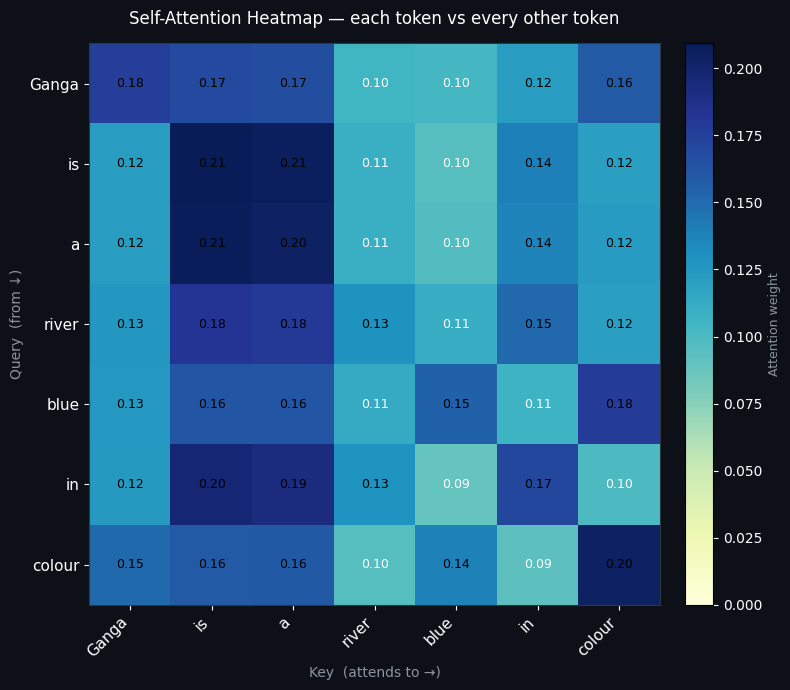

In [13]:
# ── Heatmap ───────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
attn_np = attention_weights.detach().numpy()

fig, ax = plt.subplots(figsize=(8, 7), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

im = ax.imshow(attn_np, cmap='YlGnBu', aspect='auto', vmin=0, vmax=attn_np.max())

ax.set_xticks(range(len(words)))
ax.set_xticklabels(words, rotation=45, ha='right', color='white', fontsize=11)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, color='white', fontsize=11)
ax.set_xlabel('Key  (attends to →)', color='#8b949e', fontsize=10)
ax.set_ylabel('Query  (from ↓)',     color='#8b949e', fontsize=10)
ax.set_title('Self-Attention Heatmap — each token vs every other token',
             color='white', fontsize=12, pad=14)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

# value annotations inside each cell
for i in range(len(words)):
    for j in range(len(words)):
        val = attn_np[i, j]
        ax.text(j, i, f'{val:.2f}',
                ha='center', va='center', fontsize=9,
                color='black' if val > 0.12 else 'white')

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')
cbar.set_label('Attention weight', color='#8b949e', fontsize=9)

plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## Implementing self attention step by step

In [14]:
x_2 = inputs[1] #[1,3]
d_in= inputs.shape[1] #[3]
d_out = 2

In [15]:
print(x_2)
print(d_in)
print(d_out)

tensor([0.5500, 0.8700, 0.6600])
3
2


In [ ]:
7*3 = 3*2

In [55]:
torch.manual_seed(123)
w_q = torch.nn.Parameter(torch.randn(d_in,d_out))
w_k= torch.nn.Parameter(torch.randn(d_in,d_out))
w_v =torch.nn.Parameter(torch.randn(d_in,d_out))

In [56]:
print(w_q)
print(w_k)
print(w_v)

Parameter containing:
tensor([[-0.1115,  0.1204],
        [-0.3696, -0.2404],
        [-1.1969,  0.2093]], requires_grad=True)
Parameter containing:
tensor([[-0.9724, -0.7550],
        [ 0.3239, -0.1085],
        [ 0.2103, -0.3908]], requires_grad=True)
Parameter containing:
tensor([[ 0.2350,  0.6653],
        [ 0.3528,  0.9728],
        [-0.0386, -0.8861]], requires_grad=True)


In [57]:
q_2 = x_2 @ w_q #[1,3]*[3,2]= [1,2]
k_2 = x_2 @ w_k #[1,3]*[3,2]= [1,2]
v_2 = x_2 @ w_v #[1,3]*[3,2]= [1,2]

In [58]:
print(q_2)
print(k_2)
print(v_2)

tensor([-1.1729, -0.0048], grad_fn=<SqueezeBackward4>)
tensor([-0.1142, -0.7676], grad_fn=<SqueezeBackward4>)
tensor([0.4107, 0.6274], grad_fn=<SqueezeBackward4>)


In [20]:
v_2

tensor([0.4107, 0.6274], grad_fn=<SqueezeBackward4>)

In [21]:
query_2 = x_2 @ w_q # _2 because it's with respect to the 2nd input element
key_2 = x_2 @ w_k
value_2 = x_2 @ w_v

print(query_2)

tensor([-1.1729, -0.0048], grad_fn=<SqueezeBackward4>)


## LEt us do it for all tokens

In [59]:
keys = inputs @ w_k
values = inputs @ w_v

print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([7, 2])
values.shape: torch.Size([7, 2])


In [60]:
keys_2 = keys[1] # Python starts index at 0
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(0.1376, grad_fn=<DotBackward0>)


In [24]:
attn_scores_2 = query_2 @ keys.T # All attention scores for given query
print(attn_scores_2)

tensor([ 0.2172,  0.1376,  0.1730, -0.0491,  0.7616, -0.3809,  0.9268],
       grad_fn=<SqueezeBackward4>)


In [25]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1330, 0.1257, 0.1289, 0.1102, 0.1954, 0.0871, 0.2197],
       grad_fn=<SoftmaxBackward0>)


## Implementing a compact self attention class

In [61]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):

    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value

        attn_scores = queries @ keys.T # omega
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2838, 0.7886],
        [0.2911, 0.8042],
        [0.2907, 0.8035],
        [0.2785, 0.7774],
        [0.2762, 0.7727],
        [0.2832, 0.7873],
        [0.2827, 0.7866]], grad_fn=<MmBackward0>)


### `SelfAttention_v2` Explanation

Given `x.shape = (7, 3)`, `d_in = 3`, and `d_out = 2`.

#### `__init__(self, d_in, d_out, qkv_bias=False)`
This is the constructor for the self-attention module. It initializes three separate `torch.nn.Linear` layers:

*   **`self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)`**: This creates a linear transformation layer for generating queries. It takes an input of `d_in` features (which is 3 in your case) and transforms it into `d_out` features (which is 2). If `qkv_bias` is `True`, it adds a learnable bias.
*   **`self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)`**: Similar to `W_query`, this creates a linear transformation layer for generating keys. It also transforms `d_in` features into `d_out` features.
*   **`self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)`**: This creates a linear transformation layer for generating values, transforming `d_in` features into `d_out` features.

#### `forward(self, x)`
This method defines the forward pass of the self-attention mechanism. Let's trace the tensor shapes with `x` having a shape of `(7, 3)`:

1.  **`keys = self.W_key(x)`**:
    *   `x` (input embedding for all words) has shape `(7, 3)`.
    *   `self.W_key` is a linear layer `(3, 2)`. It applies a matrix multiplication `x @ W_key_matrix + b_key`.
    *   `keys` (transformed representations acting as keys) will have shape `(7, 2)`.

2.  **`queries = self.W_query(x)`**:
    *   `x` has shape `(7, 3)`.
    *   `self.W_query` is a linear layer `(3, 2)`.
    *   `queries` (transformed representations acting as queries) will have shape `(7, 2)`.

3.  **`values = self.W_value(x)`**:
    *   `x` has shape `(7, 3)`.
    *   `self.W_value` is a linear layer `(3, 2)`.
    *   `values` (transformed representations acting as values) will have shape `(7, 2)`.

4.  **`attn_scores = queries @ keys.T`**:
    *   `queries` has shape `(7, 2)`.
    *   `keys.T` (transpose of keys) has shape `(2, 7)`.
    *   The matrix multiplication `(7, 2) @ (2, 7)` results in `attn_scores` (raw attention scores for each query against all keys) having shape `(7, 7)`.
    *   Each row `i` of `attn_scores` contains the dot products of `query[i]` with every `key[j]`.

5.  **`attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)`**:
    *   `keys.shape[-1]` is `2` (the `d_out` dimension). The scores are scaled by the square root of this dimension (`2**0.5`) to help with training stability.
    *   `torch.softmax` is applied along the last dimension (`dim=-1`). This means for each query (each row of `attn_scores`), the scores are converted into a probability distribution, where all elements in a row sum to 1.
    *   `attn_weights` (normalized attention weights) will still have shape `(7, 7)`.

6.  **`context_vec = attn_weights @ values`**:
    *   `attn_weights` has shape `(7, 7)`.
    *   `values` has shape `(7, 2)`.
    *   The matrix multiplication `(7, 7) @ (7, 2)` results in `context_vec` (the final context vectors, which are weighted sums of the values) having shape `(7, 2)`.
    *   Each row of `context_vec` is the context vector for the corresponding input token, representing a refined, attention-weighted representation of that token based on its relationships with all other tokens.

In [62]:
class SelfAttention_v2(nn.Module):

    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        print(attn_weights)
        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[0.1604, 0.1375, 0.1379, 0.1294, 0.1437, 0.1260, 0.1651],
        [0.1694, 0.1377, 0.1380, 0.1242, 0.1382, 0.1226, 0.1700],
        [0.1691, 0.1378, 0.1381, 0.1244, 0.1382, 0.1229, 0.1695],
        [0.1575, 0.1405, 0.1406, 0.1324, 0.1400, 0.1318, 0.1572],
        [0.1548, 0.1411, 0.1412, 0.1343, 0.1402, 0.1340, 0.1543],
        [0.1621, 0.1393, 0.1395, 0.1292, 0.1395, 0.1281, 0.1623],
        [0.1596, 0.1386, 0.1390, 0.1304, 0.1421, 0.1281, 0.1622]],
       grad_fn=<SoftmaxBackward0>)
tensor([[-0.0411,  0.1219],
        [-0.0409,  0.1226],
        [-0.0410,  0.1224],
        [-0.0445,  0.1171],
        [-0.0453,  0.1158],
        [-0.0430,  0.1194],
        [-0.0424,  0.1201]], grad_fn=<MmBackward0>)


In [28]:
inputs.shape

torch.Size([7, 3])

## Let us try aply causal mask

In [32]:
# Reuse the query and key weight matrices of the
# SelfAttention_v2 object from the previous section for convenience
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T

attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[0.1604, 0.1375, 0.1379, 0.1294, 0.1437, 0.1260, 0.1651],
        [0.1694, 0.1377, 0.1380, 0.1242, 0.1382, 0.1226, 0.1700],
        [0.1691, 0.1378, 0.1381, 0.1244, 0.1382, 0.1229, 0.1695],
        [0.1575, 0.1405, 0.1406, 0.1324, 0.1400, 0.1318, 0.1572],
        [0.1548, 0.1411, 0.1412, 0.1343, 0.1402, 0.1340, 0.1543],
        [0.1621, 0.1393, 0.1395, 0.1292, 0.1395, 0.1281, 0.1623],
        [0.1596, 0.1386, 0.1390, 0.1304, 0.1421, 0.1281, 0.1622]],
       grad_fn=<SoftmaxBackward0>)


In [33]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1.]])


Then, we can multiply the attention weights with this mask to zero out the attention scores above the diagonal:

In [34]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1604, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1694, 0.1377, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1691, 0.1378, 0.1381, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1575, 0.1405, 0.1406, 0.1324, 0.0000, 0.0000, 0.0000],
        [0.1548, 0.1411, 0.1412, 0.1343, 0.1402, 0.0000, 0.0000],
        [0.1621, 0.1393, 0.1395, 0.1292, 0.1395, 0.1281, 0.0000],
        [0.1596, 0.1386, 0.1390, 0.1304, 0.1421, 0.1281, 0.1622]],
       grad_fn=<MulBackward0>)


- However, if the mask were applied after softmax, like above, it would
disrupt the probability distribution created by softmax

- Softmax ensures that all output values sum to 1

- Masking after softmax would require re-normalizing the outputs to sum to 1 again, which complicates the process and might lead to unintended effects

To make sure that the rows sum to 1, we can normalize the attention weights as follows:

In [35]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529, 0.0000],
        [0.1596, 0.1386, 0.1390, 0.1304, 0.1421, 0.1281, 0.1622]],
       grad_fn=<DivBackward0>)


While we are technically done with coding the causal attention mechanism now, let's briefly look at a more efficient approach to achieve the same as above

So, instead of zeroing out attention weights above the diagonal and renormalizing the results, we can mask the unnormalized attention scores above the diagonal with negative infinity before they enter the softmax function:

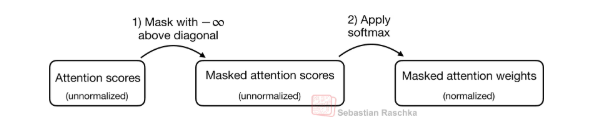

In [36]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[ 2.8991e-01,        -inf,        -inf,        -inf,        -inf,
                -inf,        -inf],
        [ 4.6564e-01,  1.7226e-01,        -inf,        -inf,        -inf,
                -inf,        -inf],
        [ 4.5944e-01,  1.7032e-01,  1.7308e-01,        -inf,        -inf,
                -inf,        -inf],
        [ 2.6416e-01,  1.0239e-01,  1.0365e-01,  1.8641e-02,        -inf,
                -inf,        -inf],
        [ 2.1829e-01,  8.7353e-02,  8.8188e-02,  1.7709e-02,  7.8567e-02,
                -inf,        -inf],
        [ 3.4078e-01,  1.2703e-01,  1.2903e-01,  1.9793e-02,  1.2897e-01,
          7.7567e-03,        -inf],
        [ 2.8596e-01,  8.6908e-02,  9.0049e-02,  5.0612e-05,  1.2153e-01,
         -2.4676e-02,  3.0875e-01]], grad_fn=<MaskedFillBackward0>)


As we can see below, now the attention weights in each row correctly sum to 1 again:

In [37]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529, 0.0000],
        [0.1596, 0.1386, 0.1390, 0.1304, 0.1421, 0.1281, 0.1622]],
       grad_fn=<SoftmaxBackward0>)
